# **Hackathon ONE G9 - Análisis Financiero Inteligente**



## 1. Objetivo del proyecto
### Descripción:
<p style='font-size: 18px'>Construir progresivamente, dentro de un notebook reproducible, los dos modelos del proyecto: el clasificador de transacciones y el modelo de perfil financiero con probabilidad. Al final, los modelos quedan serializados, subidos a Object Storage y verificados con el servicio de Python que consume el backend.</p>

## 2. Importación de librerías

In [46]:
import os
import json
import random
import joblib
import numpy as np
import pandas as pd
from faker import Faker

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns 

## 3. Configuración del entorno


In [47]:
# Inicializar Faker y semillas para reproducibilidad
fake = Faker(['es_CO', 'es_MX', 'es_ES'])
np.random.seed(42)
random.seed(42)

In [48]:
# Estilo para las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Entorno configurado y semillas fijadas correctamente.")

✅ Entorno configurado y semillas fijadas correctamente.


## 4. Carga del conjunto de datos

# Diccionario de Datos - Finance AI MVP

## 1. Categorías de Transacciones (8 fijas)
- `alimentacion`, `transporte`, `salud`, `vivienda`, `educacion`, `ocio`, `servicios`, `otras`

## 2. Etiquetas de Perfil Financiero (3 fijas)
- `Saludable`, `En observación`, `En riesgo`

## 3. Esquema: `transacciones.csv`
| Columna | Tipo | Descripción |
| :--- | :--- | :--- |
| `fecha` | `string` (YYYY-MM-DD HH:MM:SS) | Timestamp de la transacción |
| `descripcion` | `string` | Nombre del comercio con ruido realista |
| `monto` | `float` | Monto positivo de la transacción |
| `categoria` | `string` | Una de las 8 categorías |

## 4. Esquema: `perfiles.csv`
| Columna | Tipo | Descripción |
| :--- | :--- | :--- |
| `user_id` | `string` | Identificador único de usuario |
| `ingreso` | `float` | Ingreso mensual |
| `ratio_deuda` | `float` | Deuda total / Ingreso (0.0 a 1.0) |
| `frecuencia_ahorro` | `int` | Días al mes con registro de ahorro |
| `pct_gasto_esencial` | `float` | Porcentaje de gasto en necesidades básicas |
| `tasa_gasto` | `float` | Gasto total / Ingreso |
| `perfil` | `string` | `Saludable`, `En observación`, `En riesgo` |

In [49]:
# Diccionario de comercios con llaves estandarizadas
diccionario_comercios = {
    "alimentacion": {
        "marcas": ["Supermercado Exito", "Carulla", "Jumbo", "D1", "Ara", "Oxxo", "McDonalds", "Rappi Comida", "Restaurante Don Jediondo", "Crepes and Waffles", "Panaderia Kuty"],
        "monto_mu": 10.5, "monto_sigma": 0.8
    },
    "transporte": {
        "marcas": ["Gasolinera Terpel", "Texaco", "Estacion Texaco", "Uber", "Didi Ride", "Cabify", "Peaje Cundinamarca", "Taller Automotriz Central", "Transmilenio Card"],
        "monto_mu": 9.8, "monto_sigma": 0.9
    },
    "salud": {
        "marcas": ["Drogueria Cruz Verde", "Farmatodo", "Drogas La Rebaja", "EPS Sanitas", "Laboratorio Synlab", "Consultorio Odontologico", "Optica HP"],
        "monto_mu": 10.8, "monto_sigma": 1.1
    },
    "vivienda": {
        "marcas": ["Inmobiliaria Bogota", "Pago Arriendo Apto", "Administracion Conjunto", "Homecenter", "Ferreteria El Martillo", "Easy"],
        "monto_mu": 13.5, "monto_sigma": 0.6
    },
    "educacion": {
        "marcas": ["Matricula Uniminuto", "Pension Colegio", "Platzi Subscripcion", "Udemy Online", "Coursera Course", "Libreria Panamericana"],
        "monto_mu": 11.5, "monto_sigma": 1.2
    },
    "ocio": {
        "marcas": ["Cinepolis", "Cinemark", "Netflix", "Spotify", "Steam Games", "Bar El Cervecero", "Boletas Tuboleto", "Playstation Network"],
        "monto_mu": 9.5, "monto_sigma": 0.7
    },
    "servicios": {
        "marcas": ["Recarga Celular Claro", "Movistar Factura", "Enel Codensa Luz", "Vanti Gas Natural", "Acueducto Agua", "ETB Internet"],
        "monto_mu": 10.2, "monto_sigma": 0.6
    },
    "otras": {
        "marcas": ["Transferencia Nequi", "Daviplata Envio", "Cajero Davivienda", "Amazon Marketplace", "MercadoLibre", "Papeleria Comercial"],
        "monto_mu": 10.0, "monto_sigma": 1.0
    }
}

def agregar_ruido_descripcion(texto_base):
    prefijos = ["POS ", "COMPRA ", "PAGO EN ", "PAYMENT ", "AUT ", "TDA ", ""]
    prefijo = random.choice(prefijos)
    sufijo = f" #{random.randint(100, 9999)}" if random.random() < 0.6 else ""
    descripcion = f"{prefijo}{texto_base}{sufijo}"
    
    prob = random.random()
    if prob < 0.4:
        descripcion = descripcion.upper()
    elif prob < 0.7:
        descripcion = descripcion.lower()
    return descripcion

def generar_dataset_transacciones(num_registros=10000):
    categorias = list(diccionario_comercios.keys())
    registros = []
    
    for _ in range(num_registros):
        categoria = random.choice(categorias)
        info = diccionario_comercios[categoria]
        marca_base = random.choice(info["marcas"])
        descripcion = agregar_ruido_descripcion(marca_base)
        monto = round(float(np.random.lognormal(info["monto_mu"], info["monto_sigma"])), 2)
        fecha = fake.date_time_between(start_date='-1y', end_date='now').strftime('%Y-%m-%d %H:%M:%S')
        
        registros.append({
            "fecha": fecha,
            "descripcion": descripcion,
            "monto": monto,
            "categoria": categoria
        })
        
    return pd.DataFrame(registros)

df_transacciones = generar_dataset_transacciones(10000)

os.makedirs("datasets", exist_ok=True)
df_transacciones.to_csv("datasets/transacciones.csv", index=False)

print("✅ datasets/transacciones.csv generado.")
print("Distribución de clases (%):")
print((df_transacciones['categoria'].value_counts(normalize=True) * 100).round(2))

✅ datasets/transacciones.csv generado.
Distribución de clases (%):
categoria
servicios       13.06
alimentacion    12.71
otras           12.64
educacion       12.51
vivienda        12.49
ocio            12.47
salud           12.15
transporte      11.97
Name: proportion, dtype: float64


## 4. Carga del conjunto de datos

In [50]:
print("--- Auditoría Transacciones ---")
print("Filas:", len(df_transacciones))
print("Nulos:\n", df_transacciones.isnull().sum())
print("Duplicados:", df_transacciones.duplicated().sum())

print("\n--- Auditoría Perfiles ---")
print("Filas:", len(df_perfiles))
print("Nulos:\n", df_perfiles.isnull().sum())
print("Duplicados:", df_perfiles.duplicated().sum())

--- Auditoría Transacciones ---
Filas: 10000
Nulos:
 fecha          0
descripcion    0
monto          0
categoria      0
dtype: int64
Duplicados: 0

--- Auditoría Perfiles ---
Filas: 3000
Nulos:
 user_id               0
ingreso               0
ratio_deuda           0
frecuencia_ahorro     0
pct_gasto_esencial    0
tasa_gasto            0
perfil                0
dtype: int64
Duplicados: 0


In [51]:
def generar_dataset_perfiles(num_usuarios=3000):
    registros = []
    
    for i in range(1, num_usuarios + 1):
        user_id = f"USR_{i:04d}"
        ingreso = round(float(np.random.uniform(1200000, 15000000)), 2)
        ratio_deuda = round(float(np.random.uniform(0.0, 1.0)), 4)
        frecuencia_ahorro = int(np.random.randint(0, 16))
        pct_gasto_esencial = round(float(np.random.uniform(0.2, 0.9)), 4)
        tasa_gasto = round(float(np.random.uniform(0.3, 1.3)), 4)
        
        # Regla de Negocio Base
        if ratio_deuda > 0.6 or tasa_gasto > 1.0:
            perfil_base = "En riesgo"
        elif ratio_deuda > 0.3 or tasa_gasto > 0.85 or frecuencia_ahorro < 3:
            perfil_base = "En observación"
        else:
            perfil_base = "Saludable"
            
        registros.append({
            "user_id": user_id,
            "ingreso": ingreso,
            "ratio_deuda": ratio_deuda,
            "frecuencia_ahorro": frecuencia_ahorro,
            "pct_gasto_esencial": pct_gasto_esencial,
            "tasa_gasto": tasa_gasto,
            "perfil": perfil_base
        })
        
    df = pd.DataFrame(registros)
    
    # Agregar 7.5% de ruido de etiqueta
    num_ruido = int(len(df) * 0.075)
    indices_ruido = np.random.choice(df.index, size=num_ruido, replace=False)
    clases_posibles = ["Saludable", "En observación", "En riesgo"]
    
    for idx in indices_ruido:
        clase_actual = df.loc[idx, "perfil"]
        opciones = [c for c in clases_posibles if c != clase_actual]
        df.loc[idx, "perfil"] = np.random.choice(opciones)
        
    return df

df_perfiles = generar_dataset_perfiles(3000)
df_perfiles.to_csv("datasets/perfiles.csv", index=False)

print("✅ datasets/perfiles.csv generado.")
print("Distribución de perfiles (%):")
print((df_perfiles['perfil'].value_counts(normalize=True) * 100).round(2))

✅ datasets/perfiles.csv generado.
Distribución de perfiles (%):
perfil
En riesgo         54.37
En observación    30.43
Saludable         15.20
Name: proportion, dtype: float64


## 5. Exploración de datos (EDA)

In [52]:
print("--- Auditoría Transacciones ---")
print("Filas:", len(df_transacciones))
print("Nulos:\n", df_transacciones.isnull().sum())
print("Duplicados:", df_transacciones.duplicated().sum())

print("\n--- Auditoría Perfiles ---")
print("Filas:", len(df_perfiles))
print("Nulos:\n", df_perfiles.isnull().sum())
print("Duplicados:", df_perfiles.duplicated().sum())

--- Auditoría Transacciones ---
Filas: 10000
Nulos:
 fecha          0
descripcion    0
monto          0
categoria      0
dtype: int64
Duplicados: 0

--- Auditoría Perfiles ---
Filas: 3000
Nulos:
 user_id               0
ingreso               0
ratio_deuda           0
frecuencia_ahorro     0
pct_gasto_esencial    0
tasa_gasto            0
perfil                0
dtype: int64
Duplicados: 0


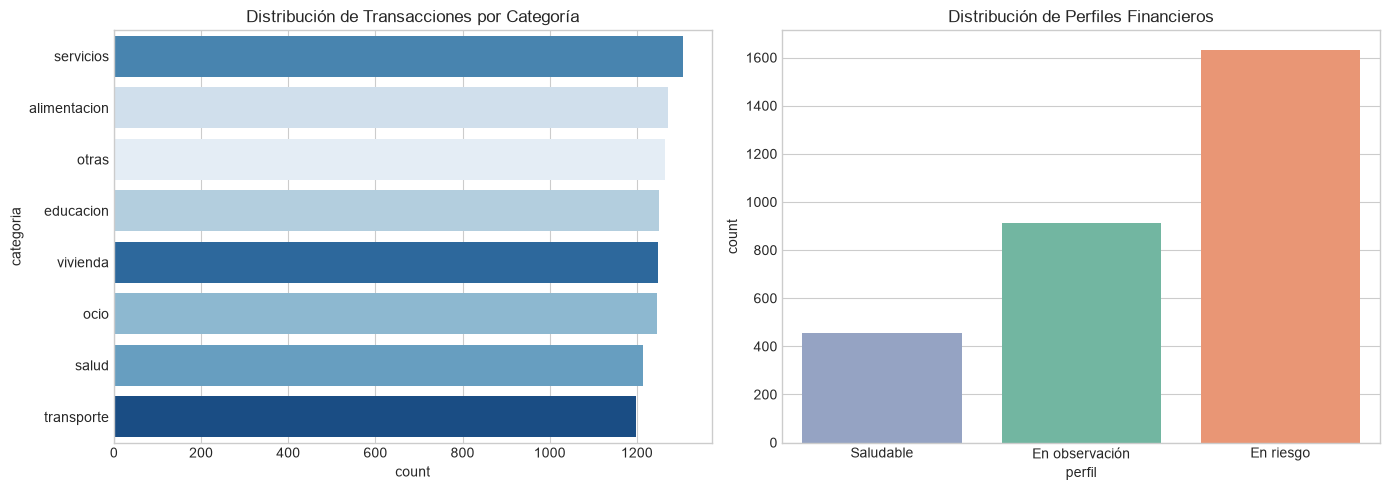

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Balance Transacciones (Sintaxis limpia sin warnings)
sns.countplot(
    data=df_transacciones, 
    y='categoria', 
    hue='categoria', # Define 'hue' explícitamente
    order=df_transacciones['categoria'].value_counts().index, 
    ax=axes[0], 
    palette='Blues_r',
    legend=False
)
axes[0].set_title('Distribución de Transacciones por Categoría')

# 2. Balance Perfiles (Sintaxis limpia sin warnings)
sns.countplot(
    data=df_perfiles, 
    x='perfil', 
    hue='perfil', # Define 'hue' explícitamente
    order=['Saludable', 'En observación', 'En riesgo'], 
    ax=axes[1], 
    palette='Set2',
    legend=False
)
axes[1].set_title('Distribución de Perfiles Financieros')

plt.tight_layout()
plt.show()

## 6. Limpieza de datos


## 7. Ingeniería de características

## 8. Preparación del conjunto de entrenamiento

## 9. Entrenamiento del modelo de clasificación de gastos

## 10. Evaluación del modelo

## 11. Modelo para perfil financiero

## 12. Generación de recomendaciones

## 13. Serialización del modelo

## 14. Pruebas del modelo

## 15. Conclusiones